<a href="https://colab.research.google.com/github/sabbirpuspo/LearningforMe/blob/main/Housing_Dataset_Assignment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [15]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [27]:
df = pd.read_csv('/content/drive/MyDrive/SkillMorph Datasets/Housing.csv')

In [17]:
# Basic exploration
print("Dataset Shape:", df.shape)

Dataset Shape: (545, 13)


In [18]:

print("\nFirst 5 rows:")
print(df.head())




First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [19]:
print("\nDataset Info:")
print(df.info())




Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [20]:
print("\nBasic Statistics:")
print(df.describe())




Basic Statistics:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [21]:
print("\nCheck for missing values:")
print(df.isnull().sum())




Check for missing values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [22]:
print("\nTarget variable distribution:")
print(df['furnishingstatus'].value_counts())


Target variable distribution:
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [23]:
# Separate input (X) and output (y)
X = df.drop('furnishingstatus', axis=1)  # Everything except furnishingstatus
y = df['furnishingstatus']                # Only furnishingstatus

print("X has all property information (12 columns)")
print("y has furnishing status (1 column)")

# Split: 80% for training, 20% for testing
# stratify=y keeps the same target ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for test
    stratify=y if y.nunique() > 1 else None,       # keep the same target ratio in train and test, if applicable
    random_state=30 # Same result every time
)

print(f"\nWe will train with: {len(X_train)} properties")
print(f"We will test with: {len(X_test)} properties")

X has all property information (12 columns)
y has furnishing status (1 column)

We will train with: 436 properties
We will test with: 109 properties


In [24]:
# Problem: Some numbers are big, some are small
print("Before scaling - different ranges:")
print(f"Price: smallest={X_train['price'].min()}, biggest={X_train['price'].max()}")
print(f"Area: smallest={X_train['area'].min()}, biggest={X_train['area'].max()}")
print("\nPrice values are in the millions, while area values are in thousands!")
print("This difference in scale can confuse machine learning models.")

Before scaling - different ranges:
Price: smallest=1750000, biggest=13300000
Area: smallest=1700, biggest=16200

Price values are in the millions, while area values are in thousands!
This difference in scale can confuse machine learning models.


In [29]:
# Identify categorical columns that are not already numerical
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical features in both training and testing sets
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Ensure both train and test sets have the same columns after encoding
# This handles cases where some categories might be missing in one set
common_cols = list(set(X_train.columns) & set(X_test.columns))
X_train = X_train[common_cols]
X_test = X_test[common_cols]

# Create scaler (changed to MinMaxScaler based on the check below)
scaler = MinMaxScaler()

# Learn from training data and scale it
X_train_minmax = scaler.fit_transform(X_train)

# Scale test data (just transform, don't fit)
X_test_minmax = scaler.transform(X_test)

print("\nAfter scaling:")
print("All features now have similar range!")
print(f"Example - First property's 'area' before scaling: {X_train['area'].iloc[0]}")
print(f"Example - First property's first feature after scaling: {X_train_minmax[0][0]:.2f}")

# Let's verify MinMaxScaler worked
print("\nChecking MinMaxScaler:")
print(f"  Minimum value: {X_train_minmax.min():.1f} (should be 0)")
print(f"  Maximum value: {X_train_minmax.max():.1f} (should be 1)")



After scaling:
All features now have similar range!
Example - First property's 'area' before scaling: 4000
Example - First property's first feature after scaling: 1.00

Checking MinMaxScaler:
  Minimum value: 0.0 (should be 0)
  Maximum value: 1.0 (should be 1)


In [30]:
# Let's create a sample dataset with text data
sample_data = pd.DataFrame({
    'area': [7420, 8960, 9960, 7500],
    'parking': ['2', '3', '3', '2'],
    'bedrooms': ['2', '3', '3', '2'],
    'guestroom': [1, 0, 1, 0]
})

print("Original data with text:")
print(sample_data)

Original data with text:
   area parking bedrooms  guestroom
0  7420       2        2          1
1  8960       3        3          0
2  9960       3        3          1
3  7500       2        2          0


In [31]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train_scaled, y_train)
print("✅ Model trained!")

# Check accuracy on training data
train_score = model.score(X_train_scaled, y_train)
print(f"Training accuracy: {train_score:.1%}")

# Check accuracy on test data
test_score = model.score(X_test_scaled, y_test)
print(f"Test accuracy: {test_score:.1%}")

✅ Model trained!
Training accuracy: 54.4%
Test accuracy: 45.0%


In [32]:
from sklearn.model_selection import cross_val_score

# Do 5-fold cross-validation
scores = cross_val_score(
    model,           # Our model
    X_train_scaled,  # Training data
    y_train,         # Training labels
    cv=10            # 5 mini-tests
)

print("5 mini-test scores:")
for i in range(10):
    print(f"  Test {i+1}: {scores[i]:.1%}")

print(f"\nAverage: {scores.mean():.1%}")
print(f"This means our model is {scores.mean():.1%} accurate!")

5 mini-test scores:
  Test 1: 50.0%
  Test 2: 50.0%
  Test 3: 38.6%
  Test 4: 45.5%
  Test 5: 59.1%
  Test 6: 34.1%
  Test 7: 44.2%
  Test 8: 32.6%
  Test 9: 44.2%
  Test 10: 62.8%

Average: 46.1%
This means our model is 46.1% accurate!


In [33]:
# Complete simple pipeline
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# 1. Load data
df = pd.read_csv('/content/drive/MyDrive/SkillMorph Datasets/Housing.csv')
print(f"Loaded {len(df)} properties")

# 2. Split X and y
X = df.drop('furnishingstatus', axis=1)
y = df['furnishingstatus']

# 3. Train-test split (stratify=y keeps the same target ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y if y.nunique() > 1 else None, random_state=42
)
print(f"Training: {len(X_train)}, Testing: {len(X_test)}")
print(f"Furnishing status ratio - train: {y_train.value_counts(normalize=True).loc['furnished']:.1%}, test: {y_test.value_counts(normalize=True).loc['furnished']:.1%}")

# Identify categorical columns that are not already numerical
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical features in both training and testing sets
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Ensure both train and test sets have the same columns after encoding
# This handles cases where some categories might be missing in one set
common_cols = list(set(X_train.columns) & set(X_test.columns))
X_train = X_train[common_cols]
X_test = X_test[common_cols]


# 4. Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data scaled")

# 5. Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Model trained")

# 6. Check accuracy
accuracy = model.score(X_test_scaled, y_test)
print(f"Accuracy: {accuracy:.1%}")

Loaded 545 properties
Training: 436, Testing: 109
Furnishing status ratio - train: 25.7%, test: 25.7%
Data scaled
Model trained
Accuracy: 48.6%


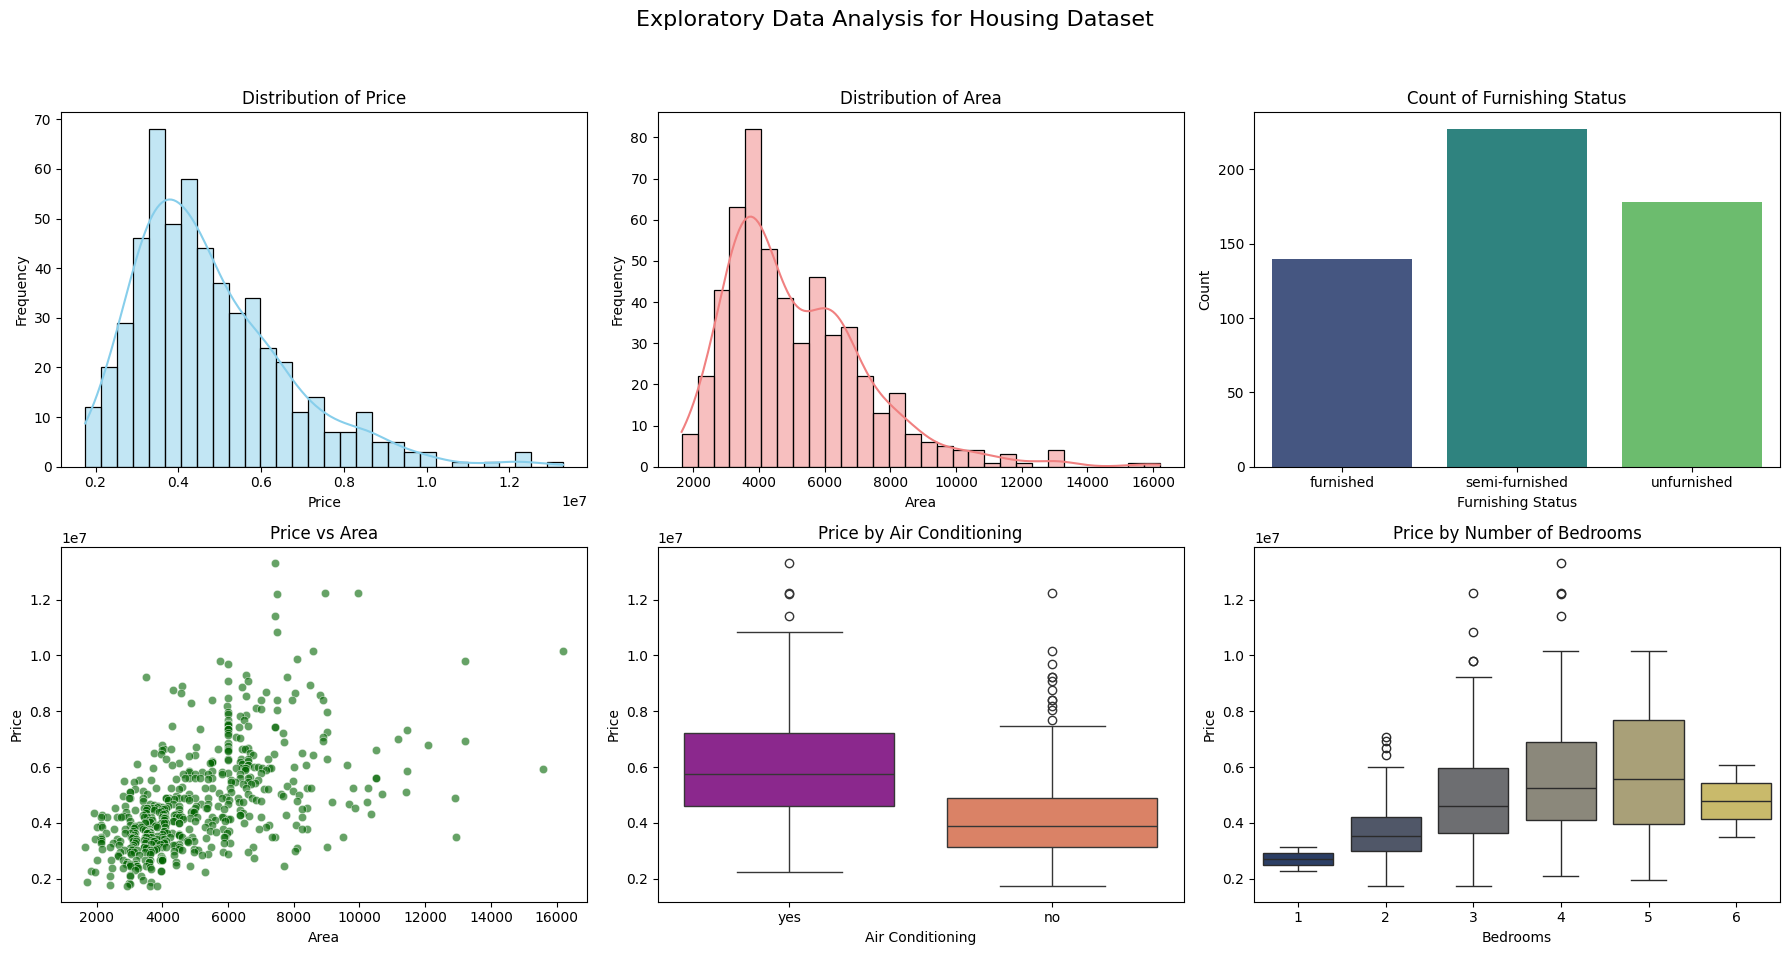

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

def quick_eda(df):
    """Six-panel EDA summary for the Housing dataset."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Exploratory Data Analysis for Housing Dataset', fontsize=16)

    # Panel 1: Distribution of Price
    sns.histplot(df['price'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Distribution of Price')
    axes[0, 0].set_xlabel('Price')
    axes[0, 0].set_ylabel('Frequency')

    # Panel 2: Distribution of Area
    sns.histplot(df['area'], bins=30, kde=True, ax=axes[0, 1], color='lightcoral')
    axes[0, 1].set_title('Distribution of Area')
    axes[0, 1].set_xlabel('Area')
    axes[0, 1].set_ylabel('Frequency')

    # Panel 3: Count of Furnishing Status
    sns.countplot(x='furnishingstatus', data=df, ax=axes[0, 2], palette='viridis')
    axes[0, 2].set_title('Count of Furnishing Status')
    axes[0, 2].set_xlabel('Furnishing Status')
    axes[0, 2].set_ylabel('Count')

    # Panel 4: Price vs Area (Scatter Plot)
    sns.scatterplot(x='area', y='price', data=df, ax=axes[1, 0], alpha=0.6, color='darkgreen')
    axes[1, 0].set_title('Price vs Area')
    axes[1, 0].set_xlabel('Area')
    axes[1, 0].set_ylabel('Price')

    # Panel 5: Price vs Air Conditioning
    sns.boxplot(x='airconditioning', y='price', data=df, ax=axes[1, 1], palette='plasma')
    axes[1, 1].set_title('Price by Air Conditioning')
    axes[1, 1].set_xlabel('Air Conditioning')
    axes[1, 1].set_ylabel('Price')

    # Panel 6: Price vs Number of Bedrooms
    sns.boxplot(x='bedrooms', y='price', data=df, ax=axes[1, 2], palette='cividis')
    axes[1, 2].set_title('Price by Number of Bedrooms')
    axes[1, 2].set_xlabel('Bedrooms')
    axes[1, 2].set_ylabel('Price')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

quick_eda(df)

In [35]:
display(df.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
